<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/05_modeling_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05. Multi‑Layer Perceptron (MLP) for Crop Suitability Prediction

In this notebook build an **MLP** classifier using the preprocessed data.
- Load the preprocessed training and test sets.
- Perform hyperparameter tuning (limited grid) with cross‑validation.
- Evaluate the best model on the test set.
- Plot the ROC curve and Precision‑Recall curve.
- Save the final model for later use.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, classification_report, confusion_matrix)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

1. Load the Preprocessed Data

In [ ]:
# Load original data
df = pd.read_csv('Crop_training_data_FULL _1.csv')

# Separate features and target
X = df.drop(columns=['suitability', 'suitability_class', 'texture'])
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0})

# Load the preprocessor fitted in the previous notebook
preprocessor = joblib.load('models/preprocessor.pkl')

X_processed = preprocessor.transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1680, 30)
Test set size: (420, 30)


2. Baseline MLP

In [ ]:
mlp_default = MLPClassifier(random_state=42, max_iter=500)
mlp_default.fit(X_train, y_train)

y_pred_default = mlp_default.predict(X_test)
y_proba_default = mlp_default.predict_proba(X_test)[:, 1]

print("Default MLP Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_default))
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall   :", recall_score(y_test, y_pred_default))
print("F1-score :", f1_score(y_test, y_pred_default))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_default))

Default MLP Performance:
Accuracy : 0.8214285714285714
Precision: 0.8453237410071942
Recall   : 0.8801498127340824
F1-score : 0.8623853211009175
ROC-AUC  : 0.8803211671684904


3. Hyperparameter Tuning with GridSearchCV

In [ ]:
# Parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

#  MLP classifier
mlp = MLPClassifier(random_state=42, max_iter=500, early_stopping=True)

# GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid,
                           cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation ROC-AUC: {:.4f}".format(grid_search.best_score_))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best cross-validation ROC-AUC: 0.8495


4. Evaluate Best Model on Test Set

In [ ]:
best_mlp = grid_search.best_estimator_
y_pred = best_mlp.predict(X_test)
y_proba = best_mlp.predict_proba(X_test)[:, 1]

print("Test Set Performance:")
print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall   : {:.4f}".format(recall_score(y_test, y_pred)))
print("F1-score : {:.4f}".format(f1_score(y_test, y_pred)))
print("ROC-AUC  : {:.4f}".format(roc_auc_score(y_test, y_proba)))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Unsuitable', 'Suitable']))

Test Set Performance:
Accuracy : 0.7857
Precision: 0.8218
Recall   : 0.8464
F1-score : 0.8339
ROC-AUC  : 0.8011

Classification Report:
              precision    recall  f1-score   support

  Unsuitable       0.72      0.68      0.70       153
    Suitable       0.82      0.85      0.83       267

    accuracy                           0.79       420
   macro avg       0.77      0.76      0.77       420
weighted avg       0.78      0.79      0.78       420



5. Confusion Matrix

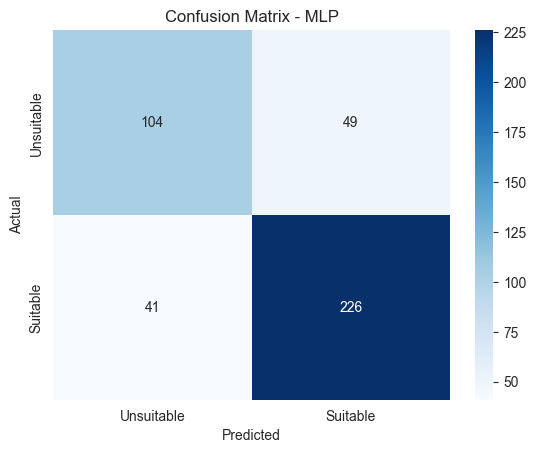

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unsuitable', 'Suitable'],
            yticklabels=['Unsuitable', 'Suitable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - MLP')
plt.show()

6. ROC Curve

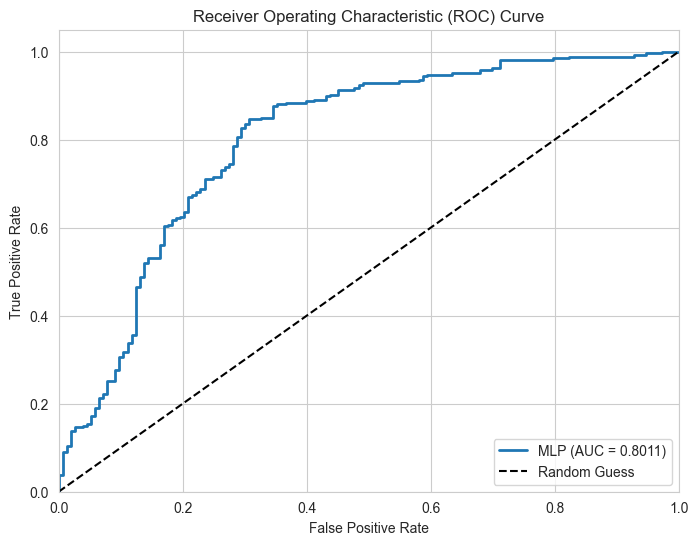

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'MLP (AUC = {roc_auc:.4f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

7. Precision‑Recall Curve

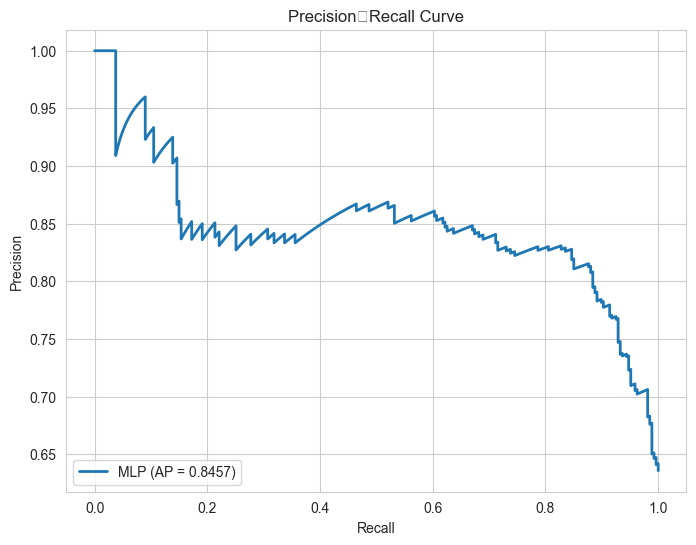

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'MLP (AP = {ap:.4f})', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

9. Save the Best Model

In [ ]:
# Save the trained MLP model
joblib.dump(best_mlp, 'models/mlp_best.pkl')
print("Model saved to ../models/mlp_best.pkl")

Model saved to ../models/mlp_best.pkl
